In [33]:
import numpy as np
from utils import annotated_heatmap
# from environments import CorridorEnvTimePenalty

We can now instantiate the environment object and some parameters such as the discount factor gamma and the policy

In [73]:
class CorridorEnvTerminalReward:
    def __init__(self, n_states=3, is_slippery = False):
        self.nS = n_states
        self.nA = 3
        self.is_slippery = is_slippery
        self.s = 0
        self.prob = 0.9
        self.terminal_s = self.nS-1        
        self.model = {}
        for s in range(self.nS):
            self.model[s] = {}
            for a in range(self.nA):
                self.model[s][a] = self.step(s, a)
        
    def reset(self):
        self.s = 0
        
    def step_environment(self, s, a):
        if a == 0: # LEFT
            shift = -1
        elif a == 1: # DON'T MOVE
            shift = 0
        elif a == 2:
            shift = +1 # RIGHT
        else:
            raise

        if self.is_slippery:
            s = np.random.choice([s+shift, s], p=[self.prob, 1 - self.prob])
        else:
            s += shift
            
        dropped = (s<0 or s>=self.nS)
        return np.clip(s, 0, self.nS-1), dropped

    def step(self, s, a):
        s_, dropped = self.step_environment(s, a)
        p1 = self.prob
        p2 = 1 - self.prob
        done = bool(s == self.terminal_s)
        r = 10.0 if done else 0.0
        return [(p1, s_, r, done), (p2, np.int64(s), r, done)] if self.is_slippery else [(1.0, s_, r, done)]
        

In [98]:
env = CorridorEnvTerminalReward(n_states=10, is_slippery=False)

n_states = env.nS
n_actions = env.nA

possible_actions = np.linspace(0, env.nA-1, env.nA)

pi = [np.ones(n_actions)/n_actions]*n_states # Set the policy to a uniform distribution
# pi = [np.array([0,0,1.0])]*n_states

In [99]:
def argmax(q_values):
    """
    Takes in a list of q_values and returns the index of the item 
    with the highest value. Breaks ties randomly.
    returns: int - the index of the highest value in q_values
    """
    top_value = float("-inf")
    ties = []
    
    for i in range(len(q_values)):
        # if a value in q_values is greater than the highest value update top and reset ties to zero
        # if a value is equal to top value add the index to ties
        # return a random selection from ties.
        if q_values[i] > top_value:
            top_value = q_values[i]
            ties = [i]
        elif q_values[i] == top_value:
            ties.append(i)
    return np.random.choice(ties)

In [137]:
def rollout_episode(env, pi):
    done = False
    s = np.random.randint(0,env.nS)
    trajectory = []    
    while not done:
        a = np.random.choice(possible_actions, p=pi[s])
        [p, s_, r, done] = env.step(s, a)[0]
        transition = [s, int(a), r]
        trajectory.append(transition)
        s = s_
    return trajectory

In [227]:
def monte_carlo_prediction(gamma: float = 1.0, num_episodes: int = 10):
    # Create unique dictionaries for every state and action using list comprehension because dict is immutable
    returns = [[{"avg_return": 0.0, "freq": 0} for _ in range(n_actions)] for _ in range(n_states)]

    # Similarly for the q-table to be safe using list comprehension because list is immutable
    q = [[0.0 for _ in range(n_actions)] for _ in range(n_states)]

    v = [0.0]*n_states # this can be defined using "*" instead of list comprehension because int is immutable

    for e in range(num_episodes):
        trajectory = rollout_episode(env, pi)
        G = 0
        for s, a, r in reversed(trajectory):
            G = G*gamma + r
            new_freq = returns[s][a]["freq"] + 1
            returns[s][a]["avg_return"] = (returns[s][a]["avg_return"]*returns[s][a]["freq"] + G)/new_freq
            returns[s][a]["freq"] = new_freq
            q[s][a] = returns[s][a]["avg_return"]
            v[s] = max(q[s])
    return v

In [228]:
v = monte_carlo_prediction(gamma=0.95, num_episodes=100)

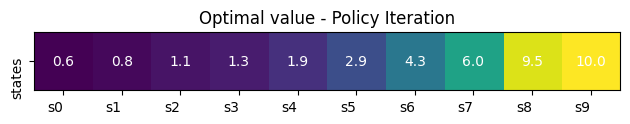

In [229]:
annotated_heatmap([v], "Optimal value - Policy Iteration")